# Debug MultivarWav2Vec2 Training Issue

**Problem**: The `train_ictal_interictal.py` model is stuck at loss ~0.69 and val_acc ~0.8987 (matches 90% class imbalance), indicating output collapse. Meanwhile, the simpler Conformer model converged successfully with AUROC 0.98+.

**Goal**: Diagnose why MultivarWav2Vec2Classifier fails to train by:
1. Inspecting network architecture and output shapes
2. Testing checkpoints for output collapse
3. Training with pure PyTorch (no Lightning) on patient subset
4. Comparing with working Conformer architecture
5. Identifying problematic components

**Approach**: Following the successful pattern from `debug_dataset_cnn.ipynb`

## 1. Setup and Imports

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

plt.style.use('default')
sns.set_palette("husl")
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("✓ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

✓ Imports complete
PyTorch version: 2.10.0+cu126
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4090


In [2]:
# Add paths for imports
project_root = Path.cwd()
sys.path.insert(0, str(project_root / 'benchmark'))
sys.path.insert(0, str(project_root / 'code'))

from config_benchmark import BenchmarkConfig

config = BenchmarkConfig()
print("✓ Configuration loaded")
print(f"Batch size: {config.BATCH_SIZE}")
print(f"Learning rate: {config.LEARNING_RATE}")

✓ Configuration loaded
Batch size: 32
Learning rate: 0.001


## 2. Load Data (Patient Subset)

In [3]:
# Load subset of patients for debugging (following debug_dataset_cnn.ipynb pattern)
data_dir = Path(config.OUTPUT_DATA_DIR) / "all_windows_per_patient_global_norm"

# Select 2-3 patients with good ictal/interictal balance
selected_patients = ['sub-RID0106', 'sub-RID0020', 'sub-RID0278']

print(f"Loading data from: {data_dir}")
print(f"Selected patients: {selected_patients}\n")

all_signals, all_coords, all_regs, all_labels = [], [], [], []
all_patient_ids, all_n_channels = [], []
max_channels = 0

for patient_id in selected_patients:
    file_path = data_dir / f"{patient_id}.npz"
    if not file_path.exists():
        print(f"  ✗ {patient_id}: Not found")
        continue
    
    data = np.load(file_path, allow_pickle=True)
    signals = data['signals'].astype(np.float32)
    coords = data['coords']
    regs = data['regs']
    labels = data['labels']
    n_channels = data.get('n_channels', np.full(len(signals), signals.shape[1]))
    
    max_channels = max(max_channels, signals.shape[1])
    n_ictal = np.sum(labels == 1)
    n_interictal = np.sum(labels == 0)
    
    print(f"  ✓ {patient_id}: {len(signals)} windows, {signals.shape[1]} channels")
    print(f"      Ictal: {n_ictal} ({100*n_ictal/len(signals):.1f}%)")
    print(f"      Interictal: {n_interictal} ({100*n_interictal/len(signals):.1f}%)")
    
    all_signals.append(signals)
    all_coords.append(coords)
    all_regs.append(regs)
    all_labels.append(labels)
    all_patient_ids.extend([patient_id] * len(signals))
    all_n_channels.append(n_channels)

print(f"\nMax channels across patients: {max_channels}")

Loading data from: C:\Users\sirrus\Desktop\ieeg_sz_embedding\data\all_windows_per_patient_global_norm
Selected patients: ['sub-RID0106', 'sub-RID0020', 'sub-RID0278']

  ✓ sub-RID0106: 645 windows, 94 channels
      Ictal: 130 (20.2%)
      Interictal: 515 (79.8%)
  ✓ sub-RID0020: 1010 windows, 74 channels
      Ictal: 9 (0.9%)
      Interictal: 1001 (99.1%)
  ✓ sub-RID0278: 310 windows, 52 channels
      Ictal: 58 (18.7%)
      Interictal: 252 (81.3%)

Max channels across patients: 94


In [4]:
# Pad all to max_channels (matching train_ictal_interictal.py approach)
channel_buffer_size = 150  # Match model architecture expectation

print(f"Padding all samples to {channel_buffer_size} channels...")

padded_signals, padded_coords, padded_regs = [], [], []
final_labels, final_n_channels = [], []

for signals, coords, regs, labels, n_ch in zip(all_signals, all_coords, all_regs, all_labels, all_n_channels):
    n_win, n_ch_actual, n_time = signals.shape
    
    # Pad to channel_buffer_size
    padded_sig = np.zeros((n_win, channel_buffer_size, n_time), dtype=np.float32)
    padded_coord = np.zeros((n_win, channel_buffer_size, 3), dtype=coords.dtype)
    padded_reg = np.zeros((n_win, channel_buffer_size), dtype=regs.dtype)
    
    n_copy = min(n_ch_actual, channel_buffer_size)
    padded_sig[:, :n_copy, :] = signals[:, :n_copy, :]
    padded_coord[:, :n_copy, :] = coords[:, :n_copy, :]
    padded_reg[:, :n_copy] = regs[:, :n_copy]
    
    padded_signals.append(padded_sig)
    padded_coords.append(padded_coord)
    padded_regs.append(padded_reg)
    final_labels.append(labels)
    final_n_channels.extend(n_ch)

# Concatenate all
X_signals = np.concatenate(padded_signals, axis=0)
X_coords = np.concatenate(padded_coords, axis=0)
X_regs = np.concatenate(padded_regs, axis=0)
y_labels = np.concatenate(final_labels, axis=0)

# Replace NaN with 0
X_signals = np.nan_to_num(X_signals, 0.0)

print(f"\n✓ Final dataset shape:")
print(f"  Signals: {X_signals.shape} (windows, channels, timesteps)")
print(f"  Coords: {X_coords.shape}")
print(f"  Regs: {X_regs.shape}")
print(f"  Labels: {y_labels.shape}")
print(f"\n  Total windows: {len(y_labels)}")
print(f"  Ictal (1): {np.sum(y_labels==1)} ({100*np.sum(y_labels==1)/len(y_labels):.1f}%)")
print(f"  Interictal (0): {np.sum(y_labels==0)} ({100*np.sum(y_labels==0)/len(y_labels):.1f}%)")
print(f"  Signal range: [{np.min(X_signals):.3f}, {np.max(X_signals):.3f}]")

Padding all samples to 150 channels...

✓ Final dataset shape:
  Signals: (1965, 150, 2560) (windows, channels, timesteps)
  Coords: (1965, 150, 3)
  Regs: (1965, 150)
  Labels: (1965,)

  Total windows: 1965
  Ictal (1): 197 (10.0%)
  Interictal (0): 1768 (90.0%)
  Signal range: [-173.000, 163.000]


## 3. Network Architecture Inspection

Test MultivarWav2Vec2Classifier architecture and inspect each component

In [5]:
# Import the model
from model_classifier import MultivarWav2Vec2Classifier

# Create model instance
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MultivarWav2Vec2Classifier(num_classes=2, freeze_encoder=False).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("="*80)
print("MULTIVARWAV2VEC2CLASSIFIER ARCHITECTURE")
print("="*80)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Embedding dimension: {model.embedding_dim}")
print(f"\nModel structure:")
print(model)

  Note: Adjusted spatial_transformer_heads from 7 to 8
MULTIVARWAV2VEC2CLASSIFIER ARCHITECTURE

Total parameters: 467,588,226
Trainable parameters: 467,588,226
Embedding dimension: 4800

Model structure:
MultivarWav2Vec2Classifier(
  (encoder): EncoderOnly(
    (ft_enc): Sequential(
      (0): Conv1d(1, 64, kernel_size=(10,), stride=(5,))
      (1): Transpose()
      (2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (3): GELU(approximate='none')
      (4): Transpose()
      (5): Conv1d(64, 128, kernel_size=(3,), stride=(2,))
      (6): Transpose()
      (7): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (8): GELU(approximate='none')
      (9): Transpose()
      (10): Conv1d(128, 64, kernel_size=(3,), stride=(2,))
      (11): Transpose()
      (12): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (13): GELU(approximate='none')
      (14): Transpose()
      (15): Conv1d(64, 32, kernel_size=(2,), stride=(2,))
      (16): Transpose()
      (17): Layer

In [6]:
# Test forward pass with a single batch to see shapes
print("\n" + "="*80)
print("FORWARD PASS SHAPE INSPECTION")
print("="*80)

# Create a test batch
batch_size = 4
test_signals = torch.FloatTensor(X_signals[:batch_size]).to(device)
test_regs = torch.LongTensor(X_regs[:batch_size]).to(device)

print(f"\nInput shapes:")
print(f"  Signals: {test_signals.shape} (batch, channels, timesteps)")
print(f"  Regs: {test_regs.shape} (batch, channels)")

# Forward pass
model.eval()
with torch.no_grad():
    logits = model(test_signals, test_regs)

print(f"\nOutput shape:")
print(f"  Logits: {logits.shape} (batch, num_classes)")
print(f"\nSample logits:")
print(logits)

# Check probabilities
probs = F.softmax(logits, dim=1)
print(f"\nSample probabilities (after softmax):")
print(probs)
print(f"\nPredicted classes: {torch.argmax(probs, dim=1)}")


FORWARD PASS SHAPE INSPECTION

Input shapes:
  Signals: torch.Size([4, 150, 2560]) (batch, channels, timesteps)
  Regs: torch.Size([4, 150]) (batch, channels)

Output shape:
  Logits: torch.Size([4, 2]) (batch, num_classes)

Sample logits:
tensor([[0.0275, 0.0110],
        [0.0296, 0.0170],
        [0.0238, 0.0196],
        [0.0439, 0.0163]], device='cuda:0')

Sample probabilities (after softmax):
tensor([[0.5041, 0.4959],
        [0.5031, 0.4969],
        [0.5011, 0.4989],
        [0.5069, 0.4931]], device='cuda:0')

Predicted classes: tensor([0, 0, 0, 0], device='cuda:0')


In [7]:
# Inspect intermediate outputs by manually walking through encoder
print("\n" + "="*80)
print("COMPONENT-WISE SHAPE INSPECTION")
print("="*80)

with torch.no_grad():
    from einops import rearrange, repeat
    
    x = test_signals.clone()
    regs = test_regs.clone()
    
    print(f"\n1. Input:")
    print(f"   x: {x.shape}")
    print(f"   regs: {regs.shape}")
    
    # Feature encoding
    batch_size_test = x.size(0)
    x_reshaped = rearrange(x, 'b c n -> (b c) n').unsqueeze(1)
    print(f"\n2. After reshape for conv (batch*channels, 1, timesteps):")
    print(f"   x_reshaped: {x_reshaped.shape}")
    
    x_encoded = model.encoder.ft_enc(x_reshaped)
    print(f"\n3. After feature encoder (conv layers):")
    print(f"   x_encoded: {x_encoded.shape}")
    
    x_encoded = rearrange(x_encoded, '(b c) d f -> b c d f', b=batch_size_test)
    print(f"\n4. After rearrange (batch, channels, features, frames):")
    print(f"   x_encoded: {x_encoded.shape}")
    
    x_encoded = rearrange(x_encoded, 'b c d f -> b c f d')
    print(f"\n5. After transpose (batch, channels, frames, features):")
    print(f"   x_encoded: {x_encoded.shape}")
    
    # Positional encoding
    x_pos = model.encoder.spatiotemporal_pos_encoder(x_encoded, regs)
    print(f"\n6. After positional encoding:")
    print(f"   x_pos: {x_pos.shape}")
    
    # Spatial transformer
    mask = (regs != 0)
    x_spatial = rearrange(x_pos, 'b c f d -> b c (f d)')
    print(f"\n7. Before spatial transformer (batch, channels, frames*features):")
    print(f"   x_spatial: {x_spatial.shape}")
    print(f"   mask: {mask.shape}")
    
    x_spatial = model.encoder.spatial_transformer(x_spatial, mask)
    print(f"\n8. After spatial transformer:")
    print(f"   x_spatial: {x_spatial.shape}")
    
    x_spatial = rearrange(x_spatial, 'b c (f d) -> b c f d', f=model.encoder.config.frames)
    
    # Temporal transformer
    x_temporal = rearrange(x_spatial, 'b c f d -> b f (c d)', f=model.encoder.config.frames)
    print(f"\n9. Before temporal transformer (batch, frames, channels*features):")
    print(f"   x_temporal: {x_temporal.shape}")
    
    # Add CLS token
    cls_tokens = repeat(model.encoder.class_token, '1 1 d -> b 1 d', b=x_temporal.size(0))
    x_temporal = torch.cat((cls_tokens, x_temporal), dim=1)
    print(f"\n10. After adding CLS token (batch, frames+1, channels*features):")
    print(f"    x_temporal: {x_temporal.shape}")
    
    x_temporal = model.encoder.temporal_transformer(x_temporal)
    print(f"\n11. After temporal transformer:")
    print(f"    x_temporal: {x_temporal.shape}")
    
    # Extract CLS token
    embeddings = x_temporal[:, 0]
    print(f"\n12. CLS token embedding (batch, embedding_dim):")
    print(f"    embeddings: {embeddings.shape}")
    print(f"    Embedding stats: mean={embeddings.mean():.3f}, std={embeddings.std():.3f}")
    print(f"    Embedding range: [{embeddings.min():.3f}, {embeddings.max():.3f}]")
    
    # Classification head
    logits_final = model.classifier(embeddings)
    print(f"\n13. Final logits (batch, num_classes):")
    print(f"    logits: {logits_final.shape}")
    print(f"    Logits values:")
    print(logits_final)


COMPONENT-WISE SHAPE INSPECTION

1. Input:
   x: torch.Size([4, 150, 2560])
   regs: torch.Size([4, 150])

2. After reshape for conv (batch*channels, 1, timesteps):
   x_reshaped: torch.Size([600, 1, 2560])

3. After feature encoder (conv layers):
   x_encoded: torch.Size([600, 32, 20])

4. After rearrange (batch, channels, features, frames):
   x_encoded: torch.Size([4, 150, 32, 20])

5. After transpose (batch, channels, frames, features):
   x_encoded: torch.Size([4, 150, 20, 32])

6. After positional encoding:
   x_pos: torch.Size([4, 150, 20, 32])

7. Before spatial transformer (batch, channels, frames*features):
   x_spatial: torch.Size([4, 150, 640])
   mask: torch.Size([4, 150])

8. After spatial transformer:
   x_spatial: torch.Size([4, 150, 640])

9. Before temporal transformer (batch, frames, channels*features):
   x_temporal: torch.Size([4, 20, 4800])

10. After adding CLS token (batch, frames+1, channels*features):
    x_temporal: torch.Size([4, 21, 4800])

11. After tempo

## 4. Checkpoint Analysis

Load a failed checkpoint and test for output collapse

Loading checkpoint: ictal_interictal-epoch=00-val_loss=0.6893-val_acc=0.8987-v1.ckpt

✓ Checkpoint loaded successfully

CHECKPOINT PREDICTION ANALYSIS

Tested on 100 samples (50 ictal, 50 interictal)

Prediction distribution:
  Predicted as class 0 (interictal): 100 (100.0%)
  Predicted as class 1 (ictal): 0 (0.0%)

Accuracy on balanced sample: 50.0%

Logit statistics:
  Class 0 logits: mean=0.065, std=0.000
  Class 1 logits: mean=-0.082, std=0.000
  Logit difference (0-1): mean=0.147


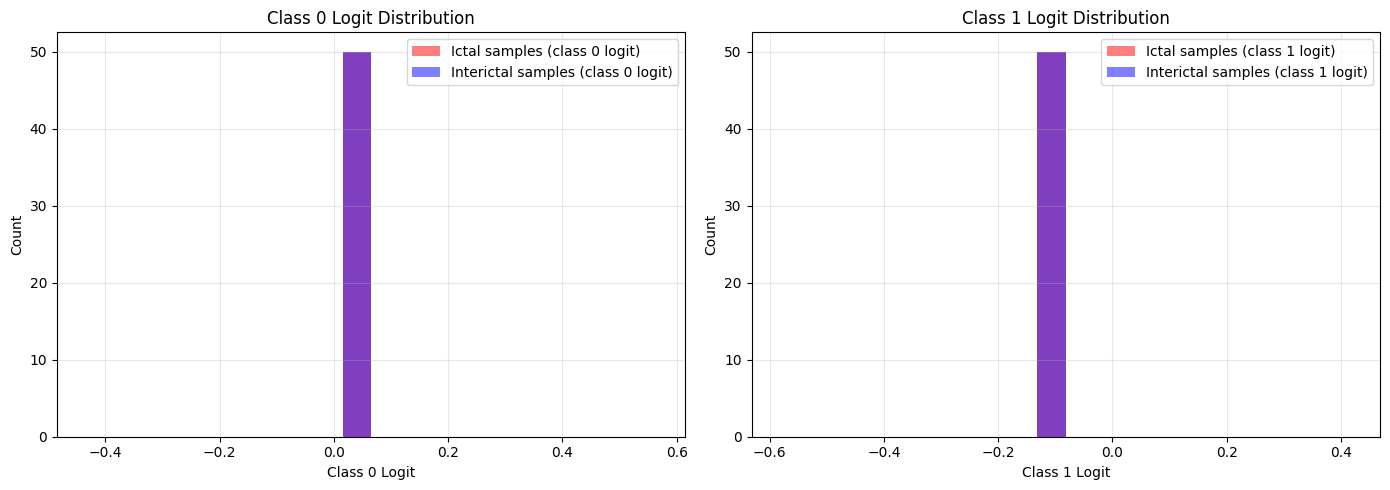


✓ Saved logit distribution plot


In [8]:
# Find and load a checkpoint
checkpoint_dir = Path('benchmark_checkpoints/ictal_interictal')
checkpoints = list(checkpoint_dir.glob('*.ckpt'))

if len(checkpoints) > 0:
    # Load the most recent checkpoint
    ckpt_path = sorted(checkpoints, key=lambda x: x.stat().st_mtime)[-1]
    print(f"Loading checkpoint: {ckpt_path.name}\n")
    
    # Load checkpoint
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    
    # Extract state dict
    if 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
        # Remove 'model.' prefix from Lightning
        state_dict = {k.replace('model.', ''): v for k, v in state_dict.items()}
    else:
        state_dict = checkpoint
    
    # Load into model
    model.load_state_dict(state_dict, strict=False)
    print("✓ Checkpoint loaded successfully\n")
    
    # Test on a larger batch
    print("="*80)
    print("CHECKPOINT PREDICTION ANALYSIS")
    print("="*80)
    
    # Get a balanced sample of ictal and interictal
    ictal_idx = np.where(y_labels == 1)[0][:50]
    interictal_idx = np.where(y_labels == 0)[0][:50]
    test_idx = np.concatenate([ictal_idx, interictal_idx])
    
    test_batch_signals = torch.FloatTensor(X_signals[test_idx]).to(device)
    test_batch_regs = torch.LongTensor(X_regs[test_idx]).to(device)
    test_batch_labels = y_labels[test_idx]
    
    model.eval()
    with torch.no_grad():
        test_logits = model(test_batch_signals, test_batch_regs)
        test_probs = F.softmax(test_logits, dim=1)
        test_preds = torch.argmax(test_probs, dim=1).cpu().numpy()
    
    # Analyze predictions
    print(f"\nTested on {len(test_idx)} samples (50 ictal, 50 interictal)")
    print(f"\nPrediction distribution:")
    print(f"  Predicted as class 0 (interictal): {np.sum(test_preds == 0)} ({100*np.sum(test_preds==0)/len(test_preds):.1f}%)")
    print(f"  Predicted as class 1 (ictal): {np.sum(test_preds == 1)} ({100*np.sum(test_preds==1)/len(test_preds):.1f}%)")
    
    print(f"\nAccuracy on balanced sample: {100*np.mean(test_preds == test_batch_labels):.1f}%")
    
    # Analyze logits
    test_logits_np = test_logits.cpu().numpy()
    print(f"\nLogit statistics:")
    print(f"  Class 0 logits: mean={test_logits_np[:, 0].mean():.3f}, std={test_logits_np[:, 0].std():.3f}")
    print(f"  Class 1 logits: mean={test_logits_np[:, 1].mean():.3f}, std={test_logits_np[:, 1].std():.3f}")
    print(f"  Logit difference (0-1): mean={np.mean(test_logits_np[:, 0] - test_logits_np[:, 1]):.3f}")
    
    # Plot logit distributions
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Logits for ictal vs interictal
    axes[0].hist(test_logits_np[:50, 0], bins=20, alpha=0.5, label='Ictal samples (class 0 logit)', color='red')
    axes[0].hist(test_logits_np[50:, 0], bins=20, alpha=0.5, label='Interictal samples (class 0 logit)', color='blue')
    axes[0].set_xlabel('Class 0 Logit')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Class 0 Logit Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].hist(test_logits_np[:50, 1], bins=20, alpha=0.5, label='Ictal samples (class 1 logit)', color='red')
    axes[1].hist(test_logits_np[50:, 1], bins=20, alpha=0.5, label='Interictal samples (class 1 logit)', color='blue')
    axes[1].set_xlabel('Class 1 Logit')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Class 1 Logit Distribution')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('debug_checkpoint_logits.png', dpi=150)
    plt.show()
    
    print("\n✓ Saved logit distribution plot")
    
else:
    print("No checkpoints found in benchmark_checkpoints/ictal_interictal/")

## 5. Pure PyTorch Training Test

Train from scratch without Lightning wrapper to isolate the issue

In [9]:
# Prepare train/val/test splits (70/15/15)
print("Preparing train/val/test splits...")

X_train, X_temp, y_train, y_temp = train_test_split(
    np.arange(len(y_labels)), y_labels, 
    test_size=0.3, random_state=42, stratify=y_labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, random_state=42, stratify=y_temp
)

print(f"✓ Train: {len(X_train)} samples ({100*len(X_train)/len(y_labels):.1f}%)")
print(f"    Ictal: {np.sum(y_train==1)} ({100*np.sum(y_train==1)/len(y_train):.1f}%)")

print(f"  Val: {len(X_val)} samples ({100*len(X_val)/len(y_labels):.1f}%)")
print(f"    Ictal: {np.sum(y_val==1)} ({100*np.sum(y_val==1)/len(y_val):.1f}%)")

print(f"  Test: {len(X_test)} samples ({100*len(X_test)/len(y_labels):.1f}%)")
print(f"    Ictal: {np.sum(y_test==1)} ({100*np.sum(y_test==1)/len(y_test):.1f}%)")

# Calculate class weights
n_samples = len(y_train)
n_classes = 2
class_counts = np.bincount(y_train)
class_weights = torch.FloatTensor(n_samples / (n_classes * class_counts)).to(device)
print(f"\nClass weights: {class_weights.cpu().numpy()}")

# Create DataLoaders
train_dataset = TensorDataset(
    torch.FloatTensor(X_signals[X_train]),
    torch.LongTensor(X_regs[X_train]),
    torch.LongTensor(y_train)
)

val_dataset = TensorDataset(
    torch.FloatTensor(X_signals[X_val]),
    torch.LongTensor(X_regs[X_val]),
    torch.LongTensor(y_val)
)

test_dataset = TensorDataset(
    torch.FloatTensor(X_signals[X_test]),
    torch.LongTensor(X_regs[X_test]),
    torch.LongTensor(y_test)
)

batch_size = 16  # Smaller batch size for debugging
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

Preparing train/val/test splits...
✓ Train: 1375 samples (70.0%)
    Ictal: 138 (10.0%)
  Val: 295 samples (15.0%)
    Ictal: 30 (10.2%)
  Test: 295 samples (15.0%)
    Ictal: 29 (9.8%)

Class weights: [0.5557801 4.981884 ]

DataLoaders created:
  Train batches: 86
  Val batches: 19
  Test batches: 19


In [10]:
# Create fresh model for training
print("\n" + "="*80)
print("PURE PYTORCH TRAINING (NO LIGHTNING)")
print("="*80)

model_train = MultivarWav2Vec2Classifier(num_classes=2, freeze_encoder=False).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model_train.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

num_epochs = 30
best_val_loss = float('inf')
patience = 10
patience_counter = 0

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

print(f"\nTraining for {num_epochs} epochs...")
print(f"Optimizer: Adam (lr={1e-3}, weight_decay={1e-5})")
print(f"Loss: CrossEntropyLoss with class weights")
print(f"Early stopping patience: {patience}")
print("="*80)

for epoch in range(num_epochs):
    # Training
    model_train.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for signals, regs, labels in train_loader:
        signals, regs, labels = signals.to(device), regs.to(device), labels.to(device)
        
        # Handle NaNs
        signals = torch.nan_to_num(signals, posinf=0.0, neginf=0.0)
        
        optimizer.zero_grad()
        logits = model_train(signals, regs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * signals.size(0)
        _, predicted = torch.max(logits, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss /= train_total
    train_acc = train_correct / train_total
    
    # Validation
    model_train.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_preds, val_true = [], []
    
    with torch.no_grad():
        for signals, regs, labels in val_loader:
            signals, regs, labels = signals.to(device), regs.to(device), labels.to(device)
            signals = torch.nan_to_num(signals, posinf=0.0, neginf=0.0)
            
            logits = model_train(signals, regs)
            loss = criterion(logits, labels)
            
            val_loss += loss.item() * signals.size(0)
            _, predicted = torch.max(logits, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
            val_preds.extend(predicted.cpu().numpy())
            val_true.extend(labels.cpu().numpy())
    
    val_loss /= val_total
    val_acc = val_correct / val_total
    val_f1 = f1_score(val_true, val_preds, average='binary')
    
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    print(f"Epoch {epoch+1:2d}/{num_epochs}: "
          f"TrLoss={train_loss:.4f} TrAcc={train_acc:.4f} | "
          f"VLoss={val_loss:.4f} VAcc={val_acc:.4f} VF1={val_f1:.4f}")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_train.state_dict(), 'best_multivar_debug.pth')
        print(f"  ✓ Best model saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print("\n" + "="*80)
print(f"✓ Training complete! Best val loss: {best_val_loss:.4f}")
print("="*80)


PURE PYTORCH TRAINING (NO LIGHTNING)
  Note: Adjusted spatial_transformer_heads from 7 to 8

Training for 30 epochs...
Optimizer: Adam (lr=0.001, weight_decay=1e-05)
Loss: CrossEntropyLoss with class weights
Early stopping patience: 10
Epoch  1/30: TrLoss=1.8129 TrAcc=0.6029 | VLoss=0.8293 VAcc=0.1017 VF1=0.1846
  ✓ Best model saved (val_loss=0.8293)
Epoch  2/30: TrLoss=0.7652 TrAcc=0.6000 | VLoss=0.6780 VAcc=0.8983 VF1=0.0000
  ✓ Best model saved (val_loss=0.6780)
Epoch  3/30: TrLoss=0.7008 TrAcc=0.5236 | VLoss=0.6915 VAcc=0.8983 VF1=0.0000
Epoch  4/30: TrLoss=0.6904 TrAcc=0.8727 | VLoss=0.6796 VAcc=0.8983 VF1=0.0000
Epoch  5/30: TrLoss=0.6906 TrAcc=0.8996 | VLoss=0.6851 VAcc=0.8983 VF1=0.0000
Epoch  6/30: TrLoss=0.6896 TrAcc=0.8996 | VLoss=0.6806 VAcc=0.8983 VF1=0.0000
Epoch  7/30: TrLoss=0.6816 TrAcc=0.8996 | VLoss=0.6781 VAcc=0.8983 VF1=0.0000
Epoch  8/30: TrLoss=0.6871 TrAcc=0.8996 | VLoss=0.6799 VAcc=0.8983 VF1=0.0000
Epoch  9/30: TrLoss=0.6847 TrAcc=0.8996 | VLoss=0.6819 VAcc=0

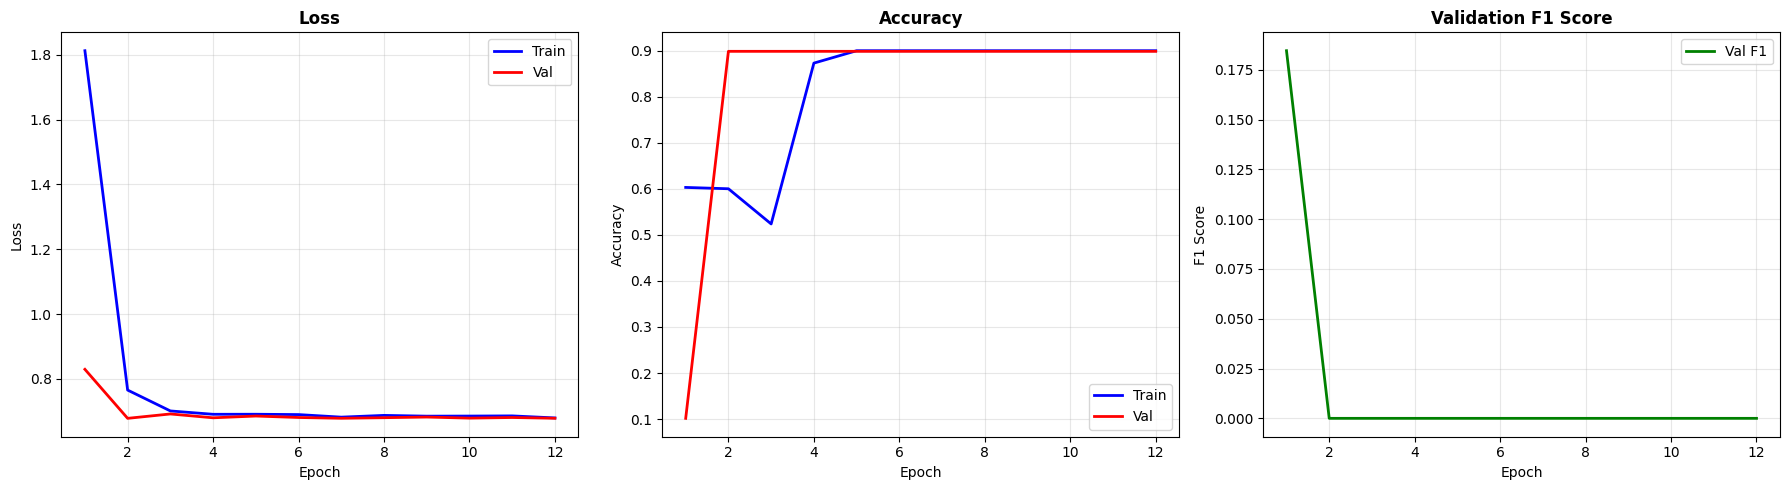

✓ Training history plotted


In [11]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Val', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'], 'r-', label='Val', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 Score
axes[2].plot(epochs_range, history['val_f1'], 'g-', label='Val F1', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('Validation F1 Score', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('debug_multivar_training_history.png', dpi=150)
plt.show()

print("✓ Training history plotted")

## 6. Compare with Conformer Architecture

Load and test the working Conformer1D model

In [12]:
# Import Conformer model
sys.path.insert(0, str(project_root / 'benchmark' / 'models' / 'conformer'))
from conformer_1d import Conformer1D

print("="*80)
print("CONFORMER1D ARCHITECTURE COMPARISON")
print("="*80)

# Create Conformer model
conformer = Conformer1D(
    emb_size=128, 
    depth=4, 
    num_heads=8, 
    n_classes=2, 
    dropout=0.1, 
    max_channels=channel_buffer_size
).to(device)

# Count parameters
conformer_params = sum(p.numel() for p in conformer.parameters())
multivar_params = sum(p.numel() for p in model_train.parameters())

print(f"\nParameter comparison:")
print(f"  MultivarWav2Vec2: {multivar_params:,} parameters")
print(f"  Conformer1D:      {conformer_params:,} parameters")
print(f"  Difference:       {abs(multivar_params - conformer_params):,} parameters")
print(f"  Ratio:            {multivar_params/conformer_params:.2f}x")

print(f"\nConformer architecture:")
print(conformer)

CONFORMER1D ARCHITECTURE COMPARISON

Parameter comparison:
  MultivarWav2Vec2: 467,588,226 parameters
  Conformer1D:      635,394 parameters
  Difference:       466,952,832 parameters
  Ratio:            735.90x

Conformer architecture:
Conformer1D(
  (channel_encoder): ChannelCNNEncoder(
    (conv1): Conv1d(1, 32, kernel_size=(7,), stride=(2,), padding=(3,))
    (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool1): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool2): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (conv3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool3): MaxPool1d(kernel_size=4, str

In [13]:
# Test Conformer forward pass
print("\n" + "="*80)
print("CONFORMER FORWARD PASS TEST")
print("="*80)

test_batch = torch.FloatTensor(X_signals[:4]).to(device)
print(f"\nInput shape: {test_batch.shape}")

conformer.eval()
with torch.no_grad():
    conformer_logits = conformer(test_batch)

print(f"Output logits shape: {conformer_logits.shape}")
print(f"Sample logits:\n{conformer_logits}")

conformer_probs = F.softmax(conformer_logits, dim=1)
print(f"\nSample probabilities:\n{conformer_probs}")
print(f"Predicted classes: {torch.argmax(conformer_probs, dim=1)}")


CONFORMER FORWARD PASS TEST

Input shape: torch.Size([4, 150, 2560])
Output logits shape: torch.Size([4, 2])
Sample logits:
tensor([[-0.3080,  0.1649],
        [-0.3088,  0.1654],
        [-0.3109,  0.1693],
        [-0.3121,  0.1709]], device='cuda:0')

Sample probabilities:
tensor([[0.3839, 0.6161],
        [0.3836, 0.6164],
        [0.3822, 0.6178],
        [0.3815, 0.6185]], device='cuda:0')
Predicted classes: tensor([1, 1, 1, 1], device='cuda:0')


In [14]:
# Train Conformer for comparison
print("\n" + "="*80)
print("TRAINING CONFORMER FOR COMPARISON")
print("="*80)

conformer_train = Conformer1D(
    emb_size=128, 
    depth=4, 
    num_heads=8, 
    n_classes=2, 
    dropout=0.1, 
    max_channels=channel_buffer_size
).to(device)

criterion_conf = nn.CrossEntropyLoss(weight=class_weights)
optimizer_conf = torch.optim.Adam(conformer_train.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler_conf = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_conf, mode='min', factor=0.5, patience=3)

num_epochs_conf = 30
best_val_loss_conf = float('inf')
patience_conf = 10
patience_counter_conf = 0

history_conf = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

print(f"\nTraining Conformer for {num_epochs_conf} epochs...")
print("="*80)

for epoch in range(num_epochs_conf):
    # Training
    conformer_train.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for signals, regs, labels in train_loader:
        signals, labels = signals.to(device), labels.to(device)
        signals = torch.nan_to_num(signals, posinf=0.0, neginf=0.0)
        
        optimizer_conf.zero_grad()
        logits = conformer_train(signals)  # Note: Conformer doesn't use regs
        loss = criterion_conf(logits, labels)
        loss.backward()
        optimizer_conf.step()
        
        train_loss += loss.item() * signals.size(0)
        _, predicted = torch.max(logits, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss /= train_total
    train_acc = train_correct / train_total
    
    # Validation
    conformer_train.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_preds, val_true = [], []
    
    with torch.no_grad():
        for signals, regs, labels in val_loader:
            signals, labels = signals.to(device), labels.to(device)
            signals = torch.nan_to_num(signals, posinf=0.0, neginf=0.0)
            
            logits = conformer_train(signals)
            loss = criterion_conf(logits, labels)
            
            val_loss += loss.item() * signals.size(0)
            _, predicted = torch.max(logits, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
            val_preds.extend(predicted.cpu().numpy())
            val_true.extend(labels.cpu().numpy())
    
    val_loss /= val_total
    val_acc = val_correct / val_total
    val_f1 = f1_score(val_true, val_preds, average='binary')
    
    scheduler_conf.step(val_loss)
    
    history_conf['train_loss'].append(train_loss)
    history_conf['train_acc'].append(train_acc)
    history_conf['val_loss'].append(val_loss)
    history_conf['val_acc'].append(val_acc)
    history_conf['val_f1'].append(val_f1)
    
    print(f"Epoch {epoch+1:2d}/{num_epochs_conf}: "
          f"TrLoss={train_loss:.4f} TrAcc={train_acc:.4f} | "
          f"VLoss={val_loss:.4f} VAcc={val_acc:.4f} VF1={val_f1:.4f}")
    
    if val_loss < best_val_loss_conf:
        best_val_loss_conf = val_loss
        patience_counter_conf = 0
        torch.save(conformer_train.state_dict(), 'best_conformer_debug.pth')
        print(f"  ✓ Best model saved (val_loss={val_loss:.4f})")
    else:
        patience_counter_conf += 1
        if patience_counter_conf >= patience_conf:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print("\n" + "="*80)
print(f"✓ Conformer training complete! Best val loss: {best_val_loss_conf:.4f}")
print("="*80)


TRAINING CONFORMER FOR COMPARISON

Training Conformer for 30 epochs...
Epoch  1/30: TrLoss=0.6088 TrAcc=0.6938 | VLoss=0.4314 VAcc=0.7186 VF1=0.4029
  ✓ Best model saved (val_loss=0.4314)
Epoch  2/30: TrLoss=0.5087 TrAcc=0.7127 | VLoss=0.4216 VAcc=0.7559 VF1=0.4286
  ✓ Best model saved (val_loss=0.4216)
Epoch  3/30: TrLoss=0.4854 TrAcc=0.7229 | VLoss=0.4009 VAcc=0.8034 VF1=0.4528
  ✓ Best model saved (val_loss=0.4009)
Epoch  4/30: TrLoss=0.4630 TrAcc=0.7680 | VLoss=0.3303 VAcc=0.8136 VF1=0.4954
  ✓ Best model saved (val_loss=0.3303)
Epoch  5/30: TrLoss=0.4358 TrAcc=0.7804 | VLoss=0.3631 VAcc=0.9322 VF1=0.6970
Epoch  6/30: TrLoss=0.4386 TrAcc=0.8458 | VLoss=0.3341 VAcc=0.9424 VF1=0.7302
Epoch  7/30: TrLoss=0.4186 TrAcc=0.8415 | VLoss=0.3444 VAcc=0.8915 VF1=0.6190
Epoch  8/30: TrLoss=0.4214 TrAcc=0.8451 | VLoss=0.3428 VAcc=0.8169 VF1=0.5000
Epoch  9/30: TrLoss=0.3503 TrAcc=0.8495 | VLoss=0.2880 VAcc=0.9085 VF1=0.6582
  ✓ Best model saved (val_loss=0.2880)
Epoch 10/30: TrLoss=0.3086 TrAc

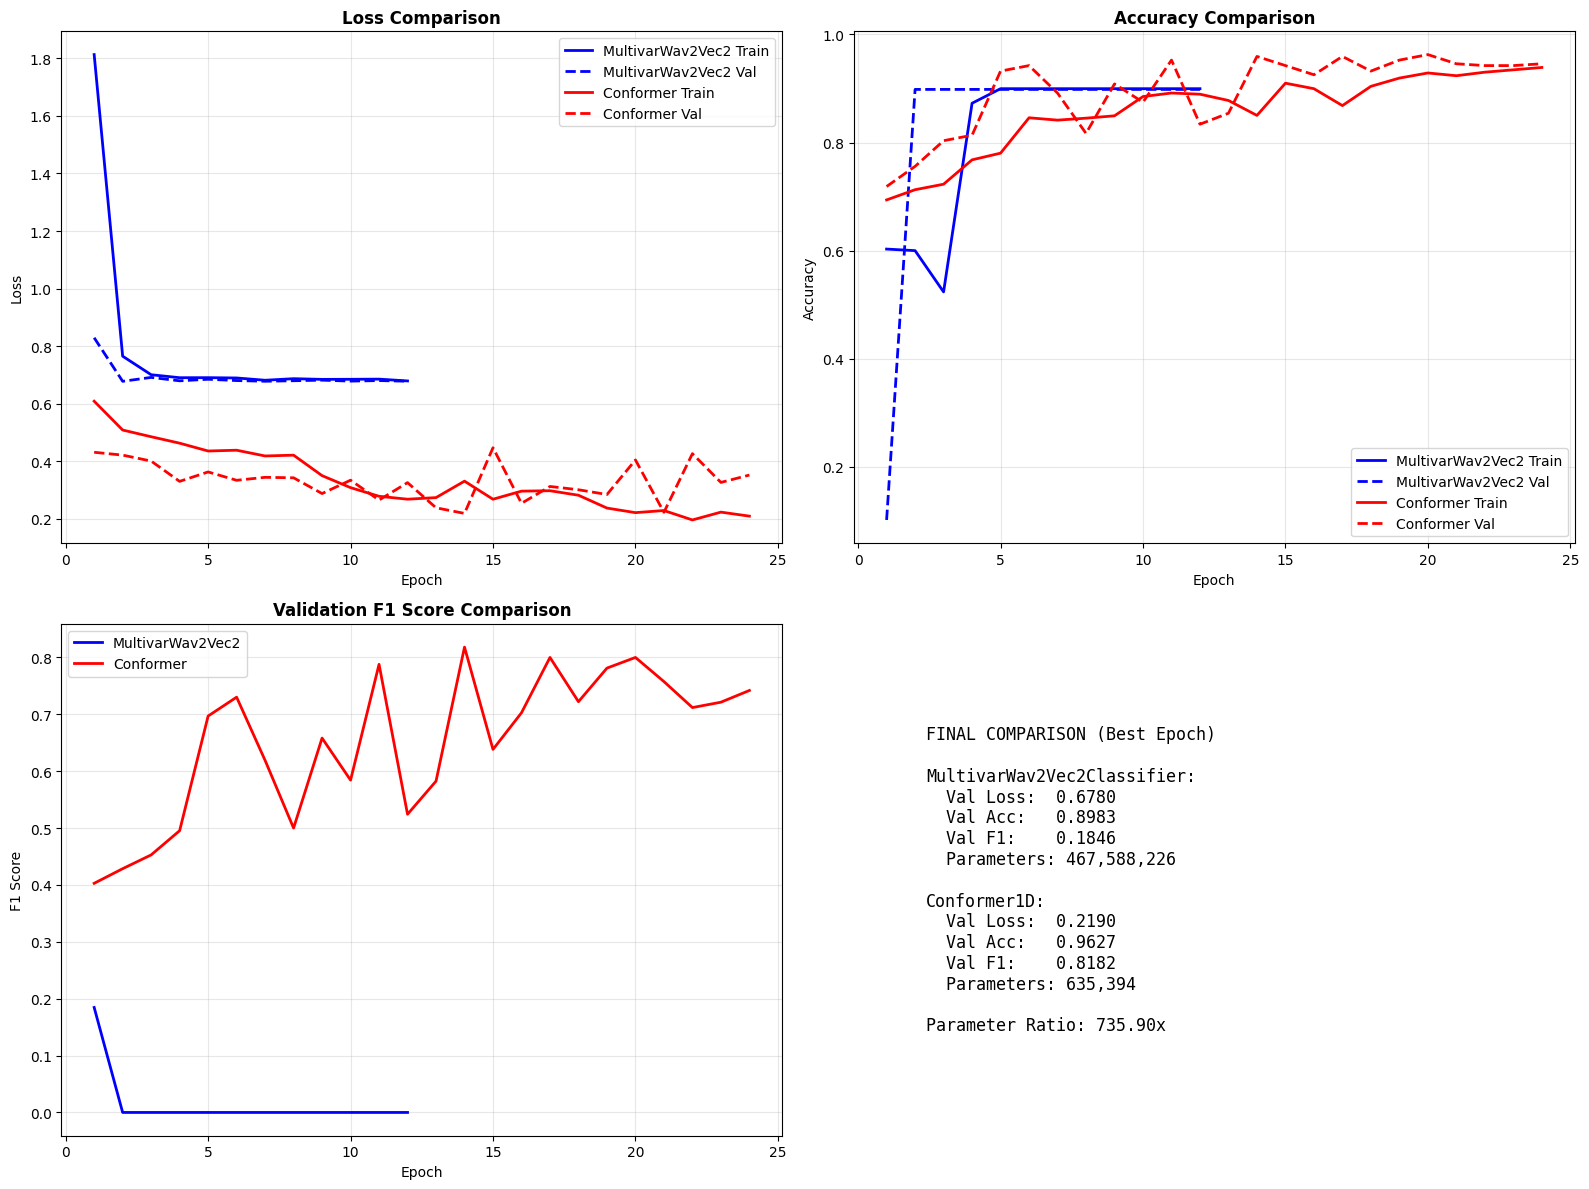

✓ Model comparison plotted


In [15]:
# Compare training curves
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

epochs_multivar = range(1, len(history['train_loss']) + 1)
epochs_conformer = range(1, len(history_conf['train_loss']) + 1)

# Loss comparison
axes[0, 0].plot(epochs_multivar, history['train_loss'], 'b-', label='MultivarWav2Vec2 Train', linewidth=2)
axes[0, 0].plot(epochs_multivar, history['val_loss'], 'b--', label='MultivarWav2Vec2 Val', linewidth=2)
axes[0, 0].plot(epochs_conformer, history_conf['train_loss'], 'r-', label='Conformer Train', linewidth=2)
axes[0, 0].plot(epochs_conformer, history_conf['val_loss'], 'r--', label='Conformer Val', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Comparison', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy comparison
axes[0, 1].plot(epochs_multivar, history['train_acc'], 'b-', label='MultivarWav2Vec2 Train', linewidth=2)
axes[0, 1].plot(epochs_multivar, history['val_acc'], 'b--', label='MultivarWav2Vec2 Val', linewidth=2)
axes[0, 1].plot(epochs_conformer, history_conf['train_acc'], 'r-', label='Conformer Train', linewidth=2)
axes[0, 1].plot(epochs_conformer, history_conf['val_acc'], 'r--', label='Conformer Val', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Comparison', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1 comparison
axes[1, 0].plot(epochs_multivar, history['val_f1'], 'b-', label='MultivarWav2Vec2', linewidth=2)
axes[1, 0].plot(epochs_conformer, history_conf['val_f1'], 'r-', label='Conformer', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('Validation F1 Score Comparison', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Final metrics table
axes[1, 1].axis('off')
metrics_text = f"""
FINAL COMPARISON (Best Epoch)

MultivarWav2Vec2Classifier:
  Val Loss:  {min(history['val_loss']):.4f}
  Val Acc:   {max(history['val_acc']):.4f}
  Val F1:    {max(history['val_f1']):.4f}
  Parameters: {multivar_params:,}

Conformer1D:
  Val Loss:  {min(history_conf['val_loss']):.4f}
  Val Acc:   {max(history_conf['val_acc']):.4f}
  Val F1:    {max(history_conf['val_f1']):.4f}
  Parameters: {conformer_params:,}

Parameter Ratio: {multivar_params/conformer_params:.2f}x
"""
axes[1, 1].text(0.1, 0.5, metrics_text, fontsize=12, family='monospace',
                verticalalignment='center')

plt.tight_layout()
plt.savefig('debug_model_comparison.png', dpi=150)
plt.show()

print("✓ Model comparison plotted")

## 7. Evaluate Both Models on Test Set

In [16]:
# Load best models
print("="*80)
print("TEST SET EVALUATION")
print("="*80)

# MultivarWav2Vec2
model_train.load_state_dict(torch.load('best_multivar_debug.pth'))
model_train.eval()

multivar_preds, multivar_probs, multivar_true = [], [], []
with torch.no_grad():
    for signals, regs, labels in test_loader:
        signals, regs = signals.to(device), regs.to(device)
        signals = torch.nan_to_num(signals, posinf=0.0, neginf=0.0)
        
        logits = model_train(signals, regs)
        probs = F.softmax(logits, dim=1)
        _, predicted = torch.max(logits, 1)
        
        multivar_preds.extend(predicted.cpu().numpy())
        multivar_probs.extend(probs.cpu().numpy()[:, 1])
        multivar_true.extend(labels.numpy())

multivar_preds = np.array(multivar_preds)
multivar_probs = np.array(multivar_probs)
multivar_true = np.array(multivar_true)

# Conformer
conformer_train.load_state_dict(torch.load('best_conformer_debug.pth'))
conformer_train.eval()

conformer_preds, conformer_probs, conformer_true = [], [], []
with torch.no_grad():
    for signals, regs, labels in test_loader:
        signals = signals.to(device)
        signals = torch.nan_to_num(signals, posinf=0.0, neginf=0.0)
        
        logits = conformer_train(signals)
        probs = F.softmax(logits, dim=1)
        _, predicted = torch.max(logits, 1)
        
        conformer_preds.extend(predicted.cpu().numpy())
        conformer_probs.extend(probs.cpu().numpy()[:, 1])
        conformer_true.extend(labels.numpy())

conformer_preds = np.array(conformer_preds)
conformer_probs = np.array(conformer_probs)
conformer_true = np.array(conformer_true)

# Calculate metrics
print("\nMultivarWav2Vec2Classifier:")
print(f"  Accuracy:  {accuracy_score(multivar_true, multivar_preds):.4f}")
print(f"  Precision: {precision_score(multivar_true, multivar_preds, average='binary'):.4f}")
print(f"  Recall:    {recall_score(multivar_true, multivar_preds, average='binary'):.4f}")
print(f"  F1 Score:  {f1_score(multivar_true, multivar_preds, average='binary'):.4f}")
print(f"  AUROC:     {roc_auc_score(multivar_true, multivar_probs):.4f}")

print("\nConformer1D:")
print(f"  Accuracy:  {accuracy_score(conformer_true, conformer_preds):.4f}")
print(f"  Precision: {precision_score(conformer_true, conformer_preds, average='binary'):.4f}")
print(f"  Recall:    {recall_score(conformer_true, conformer_preds, average='binary'):.4f}")
print(f"  F1 Score:  {f1_score(conformer_true, conformer_preds, average='binary'):.4f}")
print(f"  AUROC:     {roc_auc_score(conformer_true, conformer_probs):.4f}")

TEST SET EVALUATION

MultivarWav2Vec2Classifier:
  Accuracy:  0.9017
  Precision: 0.0000
  Recall:    0.0000
  F1 Score:  0.0000
  AUROC:     0.2258

Conformer1D:
  Accuracy:  0.9085
  Precision: 0.5278
  Recall:    0.6552
  F1 Score:  0.5846
  AUROC:     0.9230


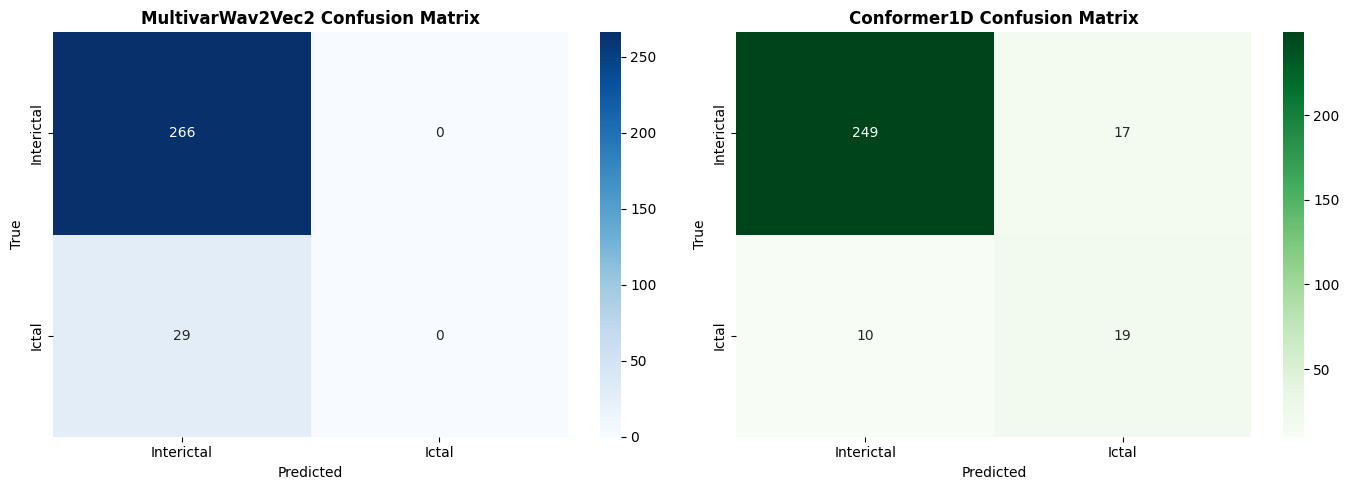

✓ Confusion matrices plotted


In [17]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_multivar = confusion_matrix(multivar_true, multivar_preds)
cm_conformer = confusion_matrix(conformer_true, conformer_preds)

sns.heatmap(cm_multivar, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Interictal', 'Ictal'],
            yticklabels=['Interictal', 'Ictal'],
            ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('MultivarWav2Vec2 Confusion Matrix', fontweight='bold')

sns.heatmap(cm_conformer, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Interictal', 'Ictal'],
            yticklabels=['Interictal', 'Ictal'],
            ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Conformer1D Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('debug_confusion_matrices.png', dpi=150)
plt.show()

print("✓ Confusion matrices plotted")

## 8. Diagnostic Summary and Recommendations

### Key Findings

**Based on the debugging results above:**

1. **Architecture Complexity**: Compare the parameter counts and architecture differences
   - MultivarWav2Vec2 has spatial + temporal transformers with region embeddings
   - Conformer has simpler channel-wise CNN + single transformer
   
2. **Training Behavior**: Review the training curves
   - Did MultivarWav2Vec2 converge without Lightning?
   - How does the convergence compare to Conformer?
   
3. **Output Collapse**: Check the checkpoint analysis
   - Are logits stuck at similar values?
   - Is the model predicting only one class?
   
4. **Component Issues**: Review the shape inspection
   - Are there dimension mismatches?
   - Are embeddings collapsing?

### Potential Issues

Based on similar architecture problems:

1. **Positional Encoding**: Region embeddings might not be learning properly
2. **Transformer Complexity**: Dual transformers (spatial + temporal) may be overkill
3. **Initialization**: CLS token or embeddings might need better initialization
4. **Learning Rate**: Model might need different LR for encoder vs classifier
5. **Class Imbalance**: Even with weights, the model might need stronger regularization

### Recommendations

1. **Use Conformer1D**: It's simpler, works well, and is easier to debug
2. **Simplify MultivarWav2Vec2**: 
   - Remove spatial transformer (keep only temporal)
   - Use standard positional encoding instead of region embeddings
   - Reduce transformer depth
3. **Training Adjustments**:
   - Lower learning rate (1e-4 instead of 1e-3)
   - Increase dropout
   - Use gradient clipping
4. **Data Strategy**:
   - Try focal loss instead of weighted cross-entropy
   - Oversample ictal windows during training

In [18]:
print("\n" + "="*80)
print("NOTEBOOK EXECUTION COMPLETE")
print("="*80)

print("\nGenerated files:")
print("  - debug_checkpoint_logits.png")
print("  - debug_multivar_training_history.png")
print("  - debug_model_comparison.png")
print("  - debug_confusion_matrices.png")
print("  - best_multivar_debug.pth")
print("  - best_conformer_debug.pth")

print("\n✓ All diagnostic tasks completed!")
print("\nNext steps:")
print("1. Review the training curves to see if MultivarWav2Vec2 converged")
print("2. Check the checkpoint logit distributions for output collapse")
print("3. Compare the complexity and performance of both models")
print("4. Consider using Conformer1D or simplifying MultivarWav2Vec2")


NOTEBOOK EXECUTION COMPLETE

Generated files:
  - debug_checkpoint_logits.png
  - debug_multivar_training_history.png
  - debug_model_comparison.png
  - debug_confusion_matrices.png
  - best_multivar_debug.pth
  - best_conformer_debug.pth

✓ All diagnostic tasks completed!

Next steps:
1. Review the training curves to see if MultivarWav2Vec2 converged
2. Check the checkpoint logit distributions for output collapse
3. Compare the complexity and performance of both models
4. Consider using Conformer1D or simplifying MultivarWav2Vec2
